In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn

from keras.models import Sequential
from keras.layers import Dense, Activation
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense, InputLayer
from tensorflow.keras.models import Sequential
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
from tensorflow.keras.regularizers import L2

c:\Users\DECOMEI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv("rawdata_luftqualitaet.csv")
df[:5]

,humidity_inside,temperature_inside,co2_inside,temperature_heater,temperature_wall_inside,state_air_quality
0,58.94,21.955,1653,41.187,14.062,1
1,58.97,21.940,1665,40.937,14.062,1
2,57.89,22.353,1707,40.375,14.250,1
3,58.96,22.504,1981,40.875,14.375,1
4,57.74,22.515,1868,40.812,14.375,1


In [3]:
X = df.drop(columns='state_air_quality')
Y = df['state_air_quality']

display(X)
# display(Y)

,humidity_inside,temperature_inside,co2_inside,temperature_heater,temperature_wall_inside
0,58.94,21.955,1653,41.187,14.062
1,58.97,21.940,1665,40.937,14.062
2,57.89,22.353,1707,40.375,14.250
3,58.96,22.504,1981,40.875,14.375
4,57.74,22.515,1868,40.812,14.375
...,...,...,...,...,...
911,37.92,21.714,891,24.312,8.937
912,37.89,23.263,1165,52.250,10.062
913,39.82,23.043,1348,48.812,10.000
914,39.76,23.508,1470,51.375,10.312


In [4]:


scaler_X = StandardScaler() # Merkmalsskalierung mit Standardscaler
X = scaler_X.fit_transform(X)
# scaler_y = StandardScaler() # Targetvektor wird auch skaliert
# Y = scaler_y.fit_transform(Y)

In [5]:
CATEGORIES = 3

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

c:\Users\DECOMEI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 60)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           183 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203 (16.42 KB)

 Trainable params: 4,203 (16.42 KB)

 Non-trainable params: 0 (0.00 B)

None

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6434 - loss: 0.9023 - val_accuracy: 0.8478 - val_loss: 0.6357
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8347 - loss: 0.5474 - val_accuracy: 0.8967 - val_loss: 0.4246
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8839 - loss: 0.4029 - val_accuracy: 0.9076 - val_loss: 0.3439
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8975 - loss: 0.3336 - val_accuracy: 0.9130 - val_loss: 0.2935
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9044 - loss: 0.2816 - val_accuracy: 0.9130 - val_loss: 0.2476
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9112 - loss: 0.2410 - val_accuracy: 0.9130 - val_loss: 0.2103
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9290 - loss: 0.2069 - val_accuracy: 0.9293 - val_loss: 0.1786
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9426 - loss: 0.1772 - val_accuracy: 0.9348 - 

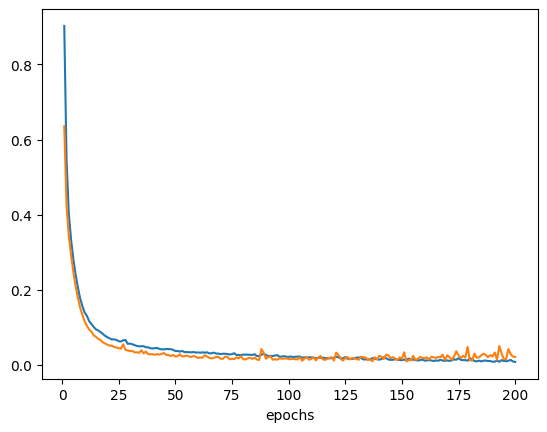

In [6]:

model = Sequential() 
model.add(InputLayer(input_shape=(5,)))
model.add(Dense(60, activation='relu'))
model.add(Dense(60, activation='relu'))
model.add(Dense(CATEGORIES, activation='softmax')) # softmax calculates the probabilities for the classes 
model.compile(
    # optimizer='sgd', # way less overfitting lol
    optimizer='adam',
    metrics=['accuracy'],
    # loss='binary_crossentropy'
    loss='sparse_categorical_crossentropy'
)

display(model.summary())

history = model.fit(x_train, y_train, epochs=200, batch_size=32, validation_data=(x_test, y_test))

loss_train = history.history['loss']
loss_test = history.history['val_loss']
plt.xlabel('epochs')
plt.plot(range(1, len(loss_train)+1), loss_train)
plt.plot(range(1, len(loss_test)+1), loss_test)


# Aufgabe 2

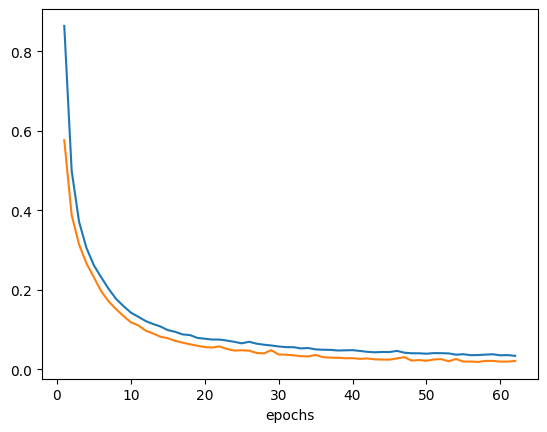

In [7]:
model = Sequential() 
model.add(InputLayer(input_shape=(5,)))
model.add(Dense(60, activation='relu'))
model.add(Dense(60, activation='relu'))
model.add(Dense(CATEGORIES, activation='softmax')) # softmax calculates the probabilities for the classes 
model.compile(
    # optimizer='sgd', # way less overfitting lol
    optimizer='adam',
    metrics=['accuracy'],
    # loss='binary_crossentropy'
    loss='sparse_categorical_crossentropy'
)

stopping = EarlyStopping(monitor='val_loss', patience=5)
checkpoint = ModelCheckpoint(filepath='keras_test_model.keras',
    monitor='val_loss',
    save_best_only=True)

history = model.fit(
    x_train, y_train, 
    epochs=200, batch_size=32, 
    validation_data=(x_test, y_test),
    callbacks=[stopping, checkpoint],
    verbose=False)

loss_train = history.history['loss']
loss_test = history.history['val_loss']
plt.xlabel('epochs')
plt.plot(range(1, len(loss_train)+1), loss_train)
plt.plot(range(1, len(loss_test)+1), loss_test)

# Aufgabe 3

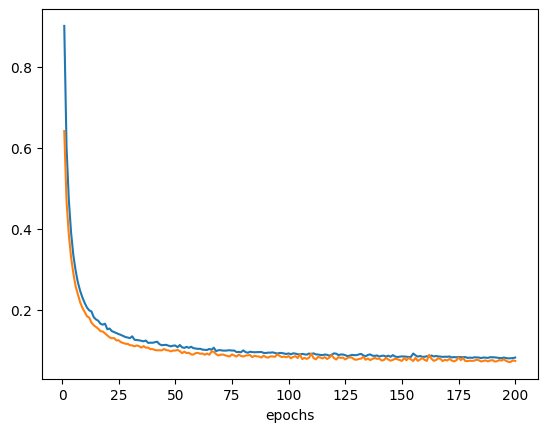

In [8]:
reg = L2(l2=.001) 
model = Sequential() 
model.add(InputLayer(input_shape=(5,)))
model.add(Dense(60, activation='relu', kernel_regularizer=reg))
model.add(Dense(60, activation='relu', kernel_regularizer=reg))
model.add(Dense(CATEGORIES, activation='softmax', kernel_regularizer=reg)) # softmax calculates the probabilities for the classes 
model.compile(
    # optimizer='sgd', # way less overfitting lol
    optimizer='adam',
    metrics=['accuracy'],
    # loss='binary_crossentropy'
    loss='sparse_categorical_crossentropy'
)

history = model.fit(
    x_train, y_train, 
    epochs=200, batch_size=32, 
    validation_data=(x_test, y_test),
    verbose=False)

loss_train = history.history['loss']
loss_test = history.history['val_loss']
plt.xlabel('epochs')
plt.plot(range(1, len(loss_train)+1), loss_train)
plt.plot(range(1, len(loss_test)+1), loss_test)